In [ ]:
# Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

In [52]:
# Função para ler arquivos do DATASUS/SINASC
def ler_sinasc(arquivo):
    df = pd.read_csv(arquivo, sep=';', skiprows=3, encoding='latin1', engine='python')
    df = df.dropna(how='all')
    
    primeira_coluna = df.columns[0]
    df = df[~df[primeira_coluna].astype(str).str.contains('Fonte|Notas', na=False)]
    
    for coluna in df.columns[1:]:
        df[coluna] = df[coluna].replace('-', 0)
        df[coluna] = pd.to_numeric(df[coluna], errors='coerce')
    
    return df

In [53]:
# Ler bases do Brasil
nasc_estado = ler_sinasc('quedas nascimento por estado.csv')
idade_mae = ler_sinasc('idade da mãe.csv')
instrucao_mae = ler_sinasc('instrução da mãe.csv')
pre_natal = ler_sinasc('consultas pre-natal.csv')
tipo_parto = ler_sinasc('tipo de parto.csv')

print(nasc_estado.head())
print(idade_mae.head())

  Região/Unidade da Federação      2010      2011      2012      2013  \
0                Região Norte  306422.0  313745.0  308375.0  313272.0   
1                 .. Rondônia   25835.0   27658.0   26513.0   27097.0   
2                     .. Acre   16495.0   17817.0   16700.0   17075.0   
3                 .. Amazonas   74188.0   76202.0   77434.0   79041.0   
4                  .. Roraima    9738.0    9945.0   10601.0   10814.0   

       2014      2015      2016      2017      2018      2019      2020  \
0  321682.0  320924.0  307526.0  312682.0  319228.0  313696.0  301635.0   
1   27560.0   27918.0   26602.0   27503.0   28091.0   27028.0   25798.0   
2   17139.0   16980.0   15773.0   16358.0   16543.0   16280.0   15142.0   
3   81145.0   80097.0   76703.0   78066.0   78087.0   77622.0   75635.0   
4   11120.0   11412.0   11376.0   11737.0   13344.0   14620.0   13760.0   

       2021      2022      2023      2024      Total  
0  309362.0  289158.0  284197.0  265670.0  4587574.0  


In [54]:
fertility = pd.read_csv('fertility.csv', sep=';')
birth_rate = pd.read_csv('birth_rate.csv', sep=';')

print(fertility.head())
print(fertility.columns.tolist())

    Country Name         Country Code  \
0         Brazil                  BRA   
1          Japan                  JPN   
2          Korea   Dem. People's Rep.   
3          China                  CHN   
4  United States                  USA   

                             Indicator Name  \
0  Fertility rate, total (births per woman)   
1  Fertility rate, total (births per woman)   
2                                       PRK   
3  Fertility rate, total (births per woman)   
4  Fertility rate, total (births per woman)   

                             Indicator Code            1960   1961   1962  \
0                            SP.DYN.TFRT.IN           6.051  6.022  5.984   
1                            SP.DYN.TFRT.IN               2  1.960  1.980   
2  Fertility rate, total (births per woman)  SP.DYN.TFRT.IN  3.568  3.261   
3                            SP.DYN.TFRT.IN           4.451  3.863  6.085   
4                            SP.DYN.TFRT.IN           3.654  3.620  3.461   

    196

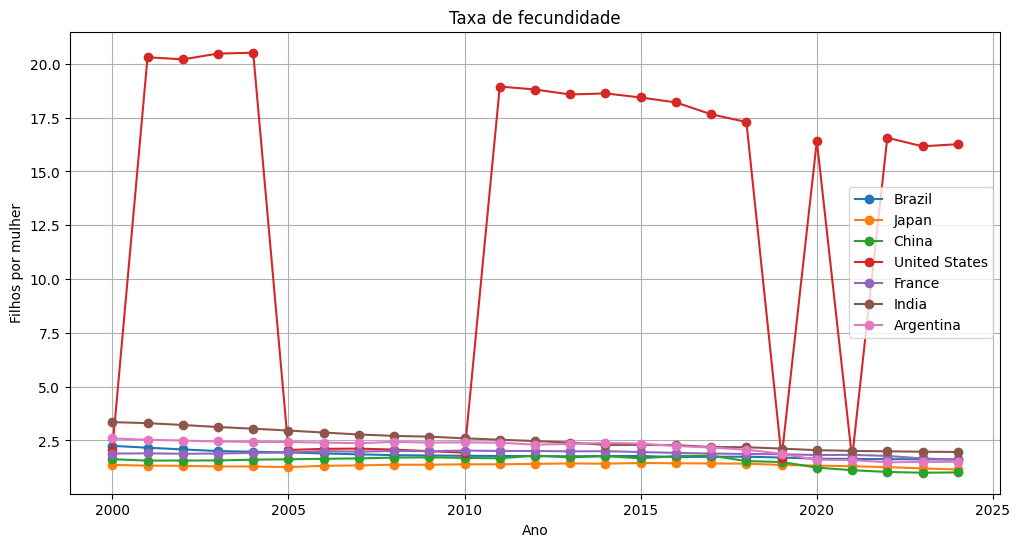

In [55]:
paises = ['Brazil', 'Japan', 'China', 'United States', 'France', 'India', 'Argentina']

anos = [str(ano) for ano in range(2000, 2025)]

fertility_paises = fertility[fertility['Country Name'].isin(paises)]

fertility_long = fertility_paises.melt(
    id_vars=['Country Name'],
    value_vars=anos,
    var_name='Ano',
    value_name='Taxa de fecundidade'
)

fertility_long['Ano'] = fertility_long['Ano'].astype(int)

plt.figure(figsize=(12,6))

for pais in paises:
    dados = fertility_long[fertility_long['Country Name'] == pais]

    plt.plot(
        dados['Ano'],
        dados['Taxa de fecundidade'],
        marker='o',
        label=pais
    )

plt.title('Taxa de fecundidade')
plt.xlabel('Ano')
plt.ylabel('Filhos por mulher')
plt.legend()
plt.grid(True)

plt.show()

In [56]:
birth_rate = pd.read_csv('birth_rate.csv', sep=';')

print(birth_rate.head())
print(birth_rate.columns.tolist())

    Country Name Country Code                        Indicator Name  \
0         Brazil          BRA  Birth rate, crude (per 1,000 people)   
1          Japan          JPN  Birth rate, crude (per 1,000 people)   
2          Korea         Rep.                                   KOR   
3          China          CHN  Birth rate, crude (per 1,000 people)   
4  United States          USA  Birth rate, crude (per 1,000 people)   

                         Indicator Code            1960    1961    1962  \
0                        SP.DYN.CBRT.IN           43.85  43.292  42.698   
1                        SP.DYN.CBRT.IN            17.2  16.900  17.000   
2  Birth rate, crude (per 1,000 people)  SP.DYN.CBRT.IN  42.073  40.851   
3                        SP.DYN.CBRT.IN           20.86  18.020  37.010   
4                        SP.DYN.CBRT.IN            23.7  23.300  22.400   

     1963    1964    1965  ...    2016    2017    2018    2019    2020  \
0  42.014  41.001  39.844  ...  14.146  14.123  

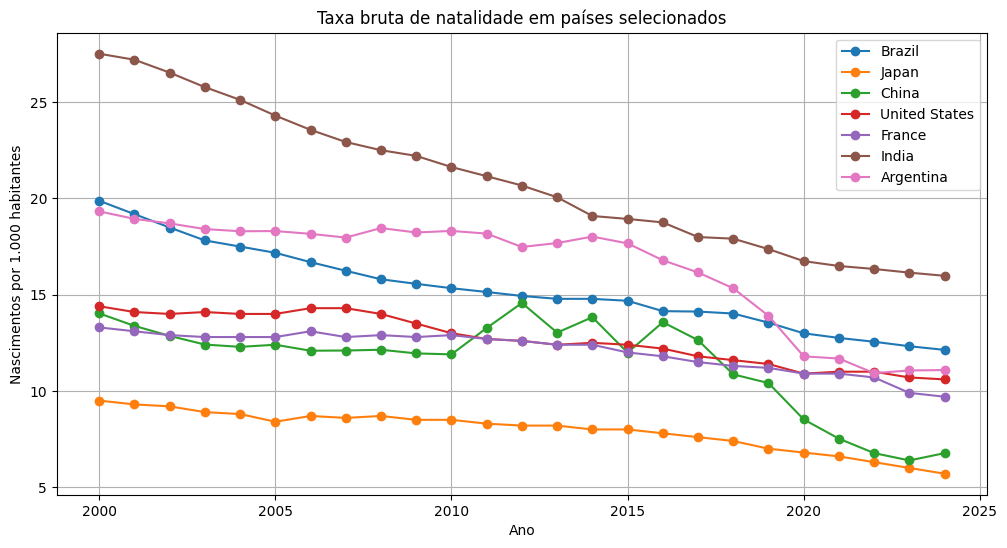

In [57]:
birth_paises = birth_rate[birth_rate['Country Name'].isin(paises)]

birth_long = birth_paises.melt(
    id_vars=['Country Name'],
    value_vars=anos,
    var_name='Ano',
    value_name='Taxa bruta de natalidade'
)

birth_long['Ano'] = birth_long['Ano'].astype(int)

plt.figure(figsize=(12, 6))

for pais in paises:
    dados = birth_long[birth_long['Country Name'] == pais]
    plt.plot(dados['Ano'], dados['Taxa bruta de natalidade'], marker='o', label=pais)

plt.title('Taxa bruta de natalidade em países selecionados')
plt.xlabel('Ano')
plt.ylabel('Nascimentos por 1.000 habitantes')
plt.legend()
plt.grid(True)
plt.show()

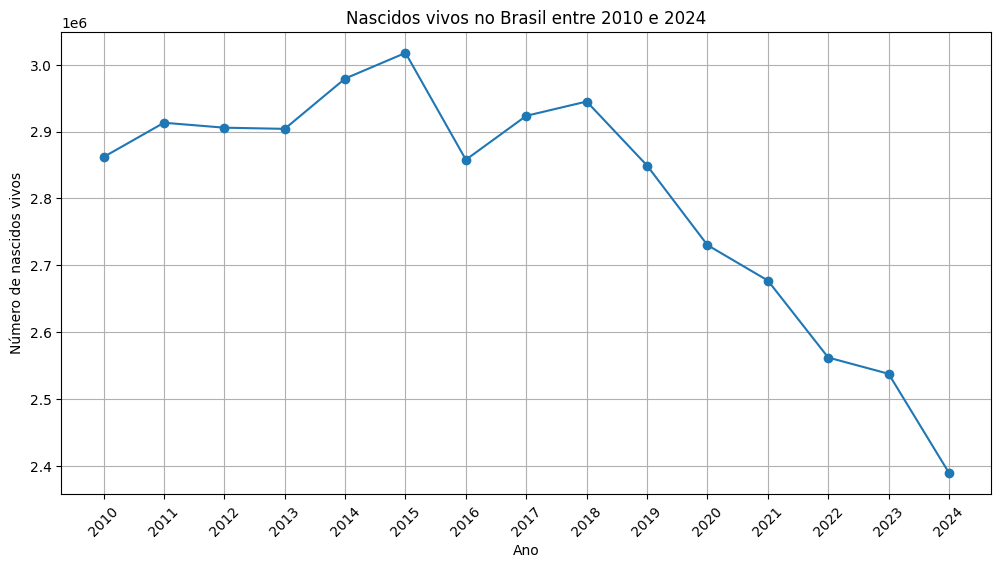

In [58]:
total_brasil = nasc_estado[nasc_estado[nasc_estado.columns[0]] == 'Total']

anos_brasil = [str(ano) for ano in range(2010, 2025)]
valores = total_brasil[anos_brasil].iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(anos_brasil, valores, marker='o')
plt.title('Nascidos vivos no Brasil entre 2010 e 2024')
plt.xlabel('Ano')
plt.ylabel('Número de nascidos vivos')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [59]:
coluna_estado = nasc_estado.columns[0]

estados = nasc_estado[nasc_estado[coluna_estado].astype(str).str.startswith('..')].copy()
estados[coluna_estado] = estados[coluna_estado].str.replace('.. ', '', regex=False)

estados['Queda_%_2010_2024'] = ((estados['2024'] - estados['2010']) / estados['2010']) * 100

ranking_queda = estados[[coluna_estado, '2010', '2024', 'Queda_%_2010_2024']]
ranking_queda = ranking_queda.sort_values('Queda_%_2010_2024')

print(ranking_queda)

   Região/Unidade da Federação      2010      2024  Queda_%_2010_2024
31            Distrito Federal   44251.0   33282.0         -24.788140
17                       Bahia  212201.0  160002.0         -24.598847
21              Rio de Janeiro  215262.0  163722.0         -23.942916
12         Rio Grande do Norte   47668.0   36612.0         -23.193757
9                     Maranhão  119566.0   92173.0         -22.910359
22                   São Paulo  601352.0  470887.0         -21.695280
2                         Acre   16495.0   13101.0         -20.575932
10                       Piauí   49424.0   39697.0         -19.680722
16                     Sergipe   34016.0   27545.0         -19.023401
14                  Pernambuco  136591.0  110827.0         -18.862151
11                       Ceará  128831.0  105453.0         -18.146254
6                        Amapá   15008.0   12327.0         -17.863806
15                     Alagoas   54164.0   45436.0         -16.114024
26           Rio Gra

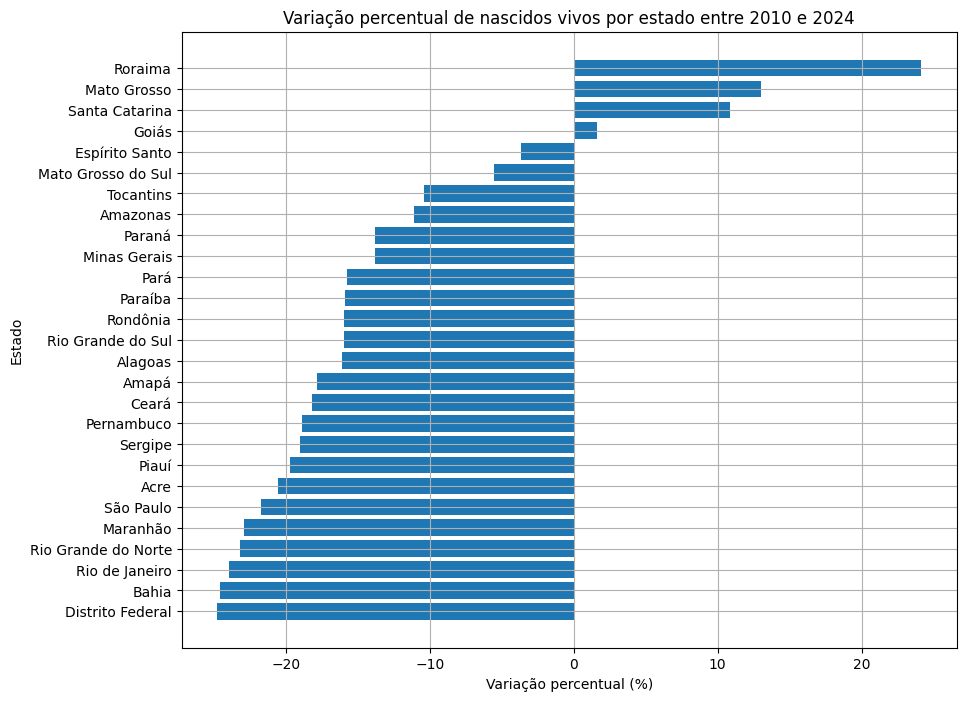

In [60]:
plt.figure(figsize=(10, 8))
plt.barh(ranking_queda[coluna_estado], ranking_queda['Queda_%_2010_2024'])
plt.title('Variação percentual de nascidos vivos por estado entre 2010 e 2024')
plt.xlabel('Variação percentual (%)')
plt.ylabel('Estado')
plt.grid(True)
plt.show()

c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

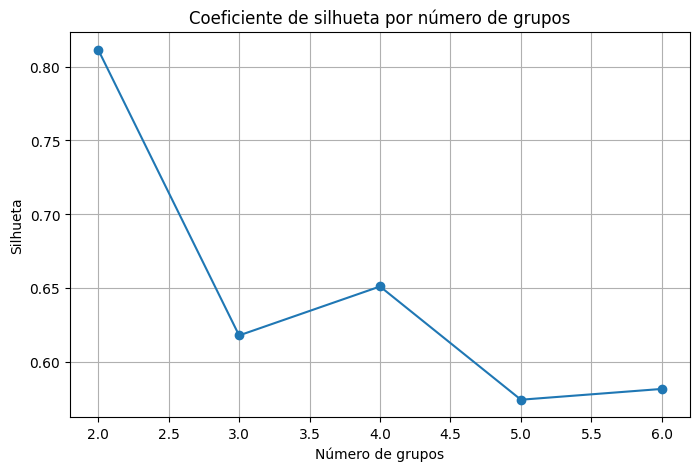

In [61]:
X = estados[anos_brasil]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhuetas = []

for k in range(2, 7):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    grupos = modelo.fit_predict(X_scaled)
    silhueta = silhouette_score(X_scaled, grupos)
    silhuetas.append(silhueta)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), silhuetas, marker='o')
plt.title('Coeficiente de silhueta por número de grupos')
plt.xlabel('Número de grupos')
plt.ylabel('Silhueta')
plt.grid(True)
plt.show()

In [62]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
estados['Cluster'] = kmeans.fit_predict(X_scaled)

resultado_cluster = estados[[coluna_estado, '2010', '2024', 'Queda_%_2010_2024', 'Cluster']]
resultado_cluster = resultado_cluster.sort_values('Cluster')

print(resultado_cluster)

   Região/Unidade da Federação      2010      2024  Queda_%_2010_2024  Cluster
1                     Rondônia   25835.0   21716.0         -15.943488        0
29                 Mato Grosso   48929.0   55310.0          13.041346        0
28          Mato Grosso do Sul   40132.0   37908.0          -5.541712        0
25              Santa Catarina   84611.0   93787.0          10.844926        0
20              Espírito Santo   51853.0   49937.0          -3.695061        0
16                     Sergipe   34016.0   27545.0         -19.023401        0
30                       Goiás   87476.0   88867.0           1.590150        0
13                     Paraíba   58699.0   49376.0         -15.882724        0
12         Rio Grande do Norte   47668.0   36612.0         -23.193757        0
15                     Alagoas   54164.0   45436.0         -16.114024        0
10                       Piauí   49424.0   39697.0         -19.680722        0
2                         Acre   16495.0   13101.0  

c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


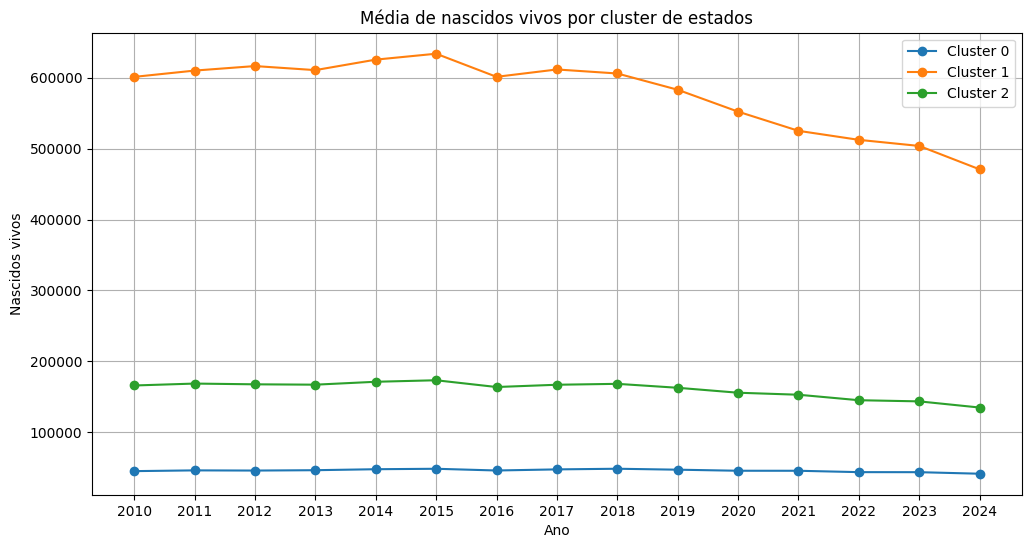

In [63]:
media_clusters = estados.groupby('Cluster')[anos_brasil].mean()

plt.figure(figsize=(12, 6))

for cluster in media_clusters.index:
    plt.plot(anos_brasil, media_clusters.loc[cluster], marker='o', label=f'Cluster {cluster}')

plt.title('Média de nascidos vivos por cluster de estados')
plt.xlabel('Ano')
plt.ylabel('Nascidos vivos')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
def transformar_longo(df, nome_variavel):
    coluna = df.columns[0]
    df = df[~df[coluna].isin(['Total', 'Ignorado'])].copy()
    
    df_long = df.melt(
        id_vars=[coluna],
        value_vars=anos_brasil,
        var_name='Ano',
        value_name='Valor'
    )
    
    df_long = df_long.rename(columns={coluna: nome_variavel})
    return df_long

In [65]:
idade_long = transformar_longo(idade_mae, 'Idade da mãe')
instrucao_long = transformar_longo(instrucao_mae, 'Instrução da mãe')
pre_natal_long = transformar_longo(pre_natal, 'Consultas pré-natal')
parto_long = transformar_longo(tipo_parto, 'Tipo de parto')

In [66]:
total_ano = total_brasil.melt(
    value_vars=anos_brasil,
    var_name='Ano',
    value_name='Nascimentos'
)

total_ano['Nascimentos_anterior'] = total_ano['Nascimentos'].shift(1)
total_ano['Queda_nascimento'] = total_ano['Nascimentos'] < total_ano['Nascimentos_anterior']
total_ano = total_ano.dropna()

print(total_ano)

     Ano  Nascimentos  Nascimentos_anterior  Queda_nascimento
1   2011    2913160.0             2861868.0             False
2   2012    2905789.0             2913160.0              True
3   2013    2904027.0             2905789.0              True
4   2014    2979259.0             2904027.0             False
5   2015    3017668.0             2979259.0             False
6   2016    2857800.0             3017668.0              True
7   2017    2923535.0             2857800.0             False
8   2018    2944932.0             2923535.0             False
9   2019    2849146.0             2944932.0              True
10  2020    2730145.0             2849146.0              True
11  2021    2677101.0             2730145.0              True
12  2022    2561922.0             2677101.0              True
13  2023    2537576.0             2561922.0              True
14  2024    2389325.0             2537576.0              True


In [67]:
def proporcao_categoria(df_long, coluna_categoria, categoria):
    base = df_long[df_long[coluna_categoria] == categoria][['Ano', 'Valor']].copy()
    total = df_long.groupby('Ano')['Valor'].sum().reset_index()
    
    base = base.merge(total, on='Ano', suffixes=('_categoria', '_total'))
    base['Proporcao'] = base['Valor_categoria'] / base['Valor_total']
    
    return base[['Ano', 'Proporcao']]

In [68]:
maes_30_34 = proporcao_categoria(idade_long, 'Idade da mãe', '30 a 34 anos')
instrucao_12 = proporcao_categoria(instrucao_long, 'Instrução da mãe', '12 anos e mais')
pre_natal_7 = proporcao_categoria(pre_natal_long, 'Consultas pré-natal', '7 ou mais consultas')
cesario = proporcao_categoria(parto_long, 'Tipo de parto', 'Cesário')

In [69]:
base_regras = total_ano[['Ano', 'Queda_nascimento']].copy()

base_regras = base_regras.merge(maes_30_34, on='Ano')
base_regras = base_regras.rename(columns={'Proporcao': 'Mae_30_34'})

base_regras = base_regras.merge(instrucao_12, on='Ano')
base_regras = base_regras.rename(columns={'Proporcao': 'Instrucao_12_mais'})

base_regras = base_regras.merge(pre_natal_7, on='Ano')
base_regras = base_regras.rename(columns={'Proporcao': 'Pre_natal_7_mais'})

base_regras = base_regras.merge(cesario, on='Ano')
base_regras = base_regras.rename(columns={'Proporcao': 'Cesario'})

print(base_regras)

     Ano  Queda_nascimento  Mae_30_34  Instrucao_12_mais  Pre_natal_7_mais  \
0   2011             False   0.181063           0.161659          0.618440   
1   2012              True   0.188512           0.155037          0.623598   
2   2013              True   0.193870           0.164817          0.631125   
3   2014             False   0.196347           0.175213          0.651108   
4   2015             False   0.199376           0.186197          0.668920   
5   2016              True   0.199486           0.192178          0.681467   
6   2017             False   0.203099           0.203456          0.696318   
7   2018             False   0.207718           0.211503          0.711473   
8   2019              True   0.209578           0.215220          0.727482   
9   2020              True   0.208530           0.218369          0.713796   
10  2021              True   0.205113           0.221245          0.735225   
11  2022              True   0.208996           0.233743        

In [70]:
base_binaria = pd.DataFrame()

base_binaria['Queda_nascimento'] = base_regras['Queda_nascimento']
base_binaria['Mae_30_34_alta'] = base_regras['Mae_30_34'] > base_regras['Mae_30_34'].median()
base_binaria['Instrucao_12_mais_alta'] = base_regras['Instrucao_12_mais'] > base_regras['Instrucao_12_mais'].median()
base_binaria['Pre_natal_7_mais_alto'] = base_regras['Pre_natal_7_mais'] > base_regras['Pre_natal_7_mais'].median()
base_binaria['Cesario_alto'] = base_regras['Cesario'] > base_regras['Cesario'].median()

print(base_binaria)

    Queda_nascimento  Mae_30_34_alta  Instrucao_12_mais_alta  \
0              False           False                   False   
1               True           False                   False   
2               True           False                   False   
3              False           False                   False   
4              False           False                   False   
5               True           False                   False   
6              False           False                   False   
7              False            True                    True   
8               True            True                    True   
9               True            True                    True   
10              True            True                    True   
11              True            True                    True   
12              True            True                    True   
13              True            True                    True   

    Pre_natal_7_mais_alto  Cesario_alto

In [71]:
itens_frequentes = apriori(
    base_binaria,
    min_support=0.3,
    use_colnames=True
)

regras = association_rules(
    itens_frequentes,
    metric='confidence',
    min_threshold=0.6
)

regras = regras.sort_values(by=['confidence', 'support'], ascending=False)

print(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                 antecedents  \
8           (Mae_30_34_alta)   
9   (Instrucao_12_mais_alta)   
10          (Mae_30_34_alta)   
11   (Pre_natal_7_mais_alto)   
14  (Instrucao_12_mais_alta)   
..                       ...   
7         (Queda_nascimento)   
25        (Queda_nascimento)   
31        (Queda_nascimento)   
42        (Queda_nascimento)   
90        (Queda_nascimento)   

                                          consequents   support  confidence  \
8                            (Instrucao_12_mais_alta)  0.500000    1.000000   
9                                    (Mae_30_34_alta)  0.500000    1.000000   
10                            (Pre_natal_7_mais_alto)  0.500000    1.000000   
11                                   (Mae_30_34_alta)  0.500000    1.000000   
14                            (Pre_natal_7_mais_alto)  0.500000    1.000000   
..                                                ...       ...         ...   
7                                      (Cesario_alto)  0.42857

In [72]:
regras_queda = regras[regras['consequents'].astype(str).str.contains('Queda_nascimento')]

print(regras_queda[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                                           antecedents  \
32                      (Mae_30_34_alta, Cesario_alto)   
43              (Instrucao_12_mais_alta, Cesario_alto)   
48               (Cesario_alto, Pre_natal_7_mais_alto)   
91   (Mae_30_34_alta, Instrucao_12_mais_alta, Cesar...   
96                      (Mae_30_34_alta, Cesario_alto)   
..                                                 ...   
164    (Instrucao_12_mais_alta, Pre_natal_7_mais_alto)   
169                                   (Mae_30_34_alta)   
170                           (Instrucao_12_mais_alta)   
171                                     (Cesario_alto)   
172                            (Pre_natal_7_mais_alto)   

                                           consequents   support  confidence  \
32                                  (Queda_nascimento)  0.357143    1.000000   
43                                  (Queda_nascimento)  0.357143    1.000000   
48                                  (Queda_nascimento)  0.35714

In [73]:
ranking_queda.to_csv('ranking_queda_estados.csv', index=False)
resultado_cluster.to_csv('clusters_estados.csv', index=False)
base_regras.to_csv('base_regras_associacao.csv', index=False)
regras.to_csv('regras_associacao.csv', index=False)